# Sprint 3 - Análise Estatística de Veículos Elétricos
## Probabilidade, Distribuição Normal e Regressão Linear

**Disciplina:** Modelagem Linear para Aprendizado de Máquina

**Integrantes:**
- Felipe Mitsuo Takahashi Stephano — RM570692
- Laura Godoy Callegari — RM569181
- Letícia Araújo Espindola — RM569308
- Mariana Dreset Carbollan — RM569207
- Milena de Aguiar Lopes Cardoso — RM570599
- Felipe Perdigão Macedo — RM570990

**Base de dados:** Electric Vehicle Population Data (mesma base da Sprint 2)

**Variável escolhida:** `Electric Range` (autonomia elétrica, em milhas)

## 1. Carregando e limpando os dados

Antes dos cálculos olhamos os dados

1. A base tem carros BEV (100% elétrico) e PHEV (híbrido, tem motor a gasolina também). Como queremos falar de autonomia elétrica, vamos usar apenas os BEV
2. Muitos carros tem Electric Range = 0. Isso é a informação que não foi preenchida na base, e se deixarmos esses valores, a média e a mediana ficam erradas, então filtramos os dados antes de começar

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Carrega o arquivo csv
df0 = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Filtrar: só carros 100% elétricos (BEV) e com autonomia preenchida (diferente de 0)
df1 = df0[(df0["Electric Vehicle Type"] == "Battery Electric Vehicle (BEV)") & (df0["Electric Range"] > 0)]

print("Total de linhas na base original:", len(df0))
print("Total de linhas depois do filtro:", len(df1))


Total de linhas na base original: 150482
Total de linhas depois do filtro: 47109


## 2. Calculando média, desvio-padrão e mediana

Essas três medidas serão necessárias para os exercícios

In [4]:
media = df1["Electric Range"].mean()
desvio = df1["Electric Range"].std()
mediana = df1["Electric Range"].median()

print(f"Média: {media:.3f} milhas")
print(f"Desvio-padrão: {desvio:.3f} milhas")
print(f"Mediana: {mediana:.3f} milhas")

Média: 194.911 milhas
Desvio-padrão: 73.770 milhas
Mediana: 215.000 milhas


## 3. Exercício 1 — Probabilidade acima da mediana

O enunciado pede pra assumir que a variável segue uma **Distribuição Normal**. Com a função `scipy.stats.norm`, dá pra calcular a probabilidade de um valor ser maior que a mediana, usando a média e o desvio-padrão que calculamos acima.

In [9]:
probabilidade = stats.norm.sf(mediana, loc=media, scale=desvio)
probabilidade_porcentagem = probabilidade * 100

print(f"A) Mediana: {mediana:.2f}")

print(f"B) Probabilidade acima da mediana: {probabilidade:.3f}")
print(f"Probabilidade em porcentagem: {probabilidade_porcentagem:.3f} %")

print("D) Classificação:")

if probabilidade < 0.05:
    print("Evento raro")
elif probabilidade < 0.50:
    print("Evento pouco provável")
elif probabilidade < 0.95:
    print("Evento provável")
else:
    print("Evento quase certo")

A) Mediana: 215.00
B) Probabilidade acima da mediana: 0.393
Probabilidade em porcentagem: 39.269 %
D) Classificação:
Evento pouco provável


## 4. Exercício 2 — Probabilidade no intervalo média

In [10]:
limite_inferior = media - 2 * desvio
limite_superior = media + 2 * desvio

probabilidade = stats.norm.cdf(limite_superior, loc=media, scale=desvio) - stats.norm.cdf(limite_inferior, loc=media, scale=desvio)

probabilidade_porcentagem = probabilidade * 100

print(f"A) Média: {media:.2f}")
print(f"Desvio-padrão: {desvio:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")

print(f"B) Probabilidade no intervalo: {probabilidade:.3f}")
print(f"Probabilidade em porcentagem: {probabilidade_porcentagem:.3f} %")

print("D) Classificação:")

if probabilidade < 0.05:
    print("Evento raro")
elif probabilidade < 0.50:
    print("Evento pouco provável")
elif probabilidade < 0.95:
    print("Evento provável")
else:
    print("Evento quase certo")

A) Média: 194.91
Desvio-padrão: 73.77
Limite inferior: 47.37
Limite superior: 342.45
B) Probabilidade no intervalo: 0.954
Probabilidade em porcentagem: 95.450 %
D) Classificação:
Evento quase certo


## 5. Exercício 3 — Regressão Linear

Variáveis escolhidas: Model Year (ano do carro) e Electric Range (autonomia). A ideia é analisar se carros mais novos tendem a ter maior autonomia.

Para a regressão, calculamos a inclinação, o intercepto e o R2 usando operações matemáticas e a média dos dados. A inclinação indica como a autonomia varia conforme o ano do carro, e o R2 mostra o quanto o modelo explica a variação dos dados

In [7]:
x = df1["Model Year"]
y = df1["Electric Range"]

media_x = x.mean()
media_y = y.mean()

inclinacao = ((x - media_x) * (y - media_y)).mean() / ((x - media_x) ** 2).mean()

intercepto = media_y - inclinacao * media_x

y_estimado = inclinacao * x + intercepto

r2 = 1 - ((y - y_estimado) ** 2).mean() / ((y - media_y) ** 2).mean()

print(f"A) Inclinação: {inclinacao:.2f}")
print(f"Intercepto: {intercepto:.2f}")
print(f"R2: {r2:.3f}")

A) Inclinação: 22.02
Intercepto: -44226.85
R2: 0.499


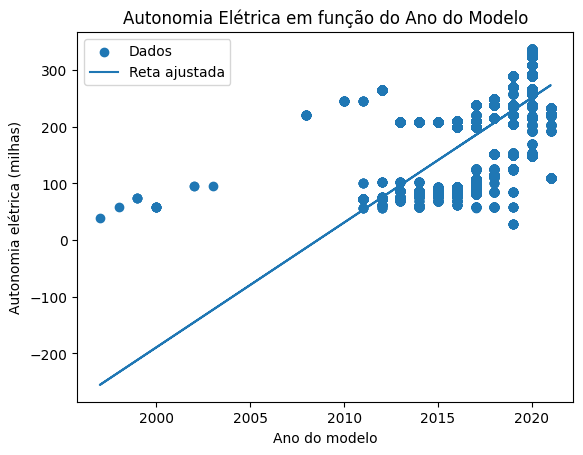

In [8]:
plt.scatter(x, y, label="Dados")

plt.plot(
    x,
    y_estimado,
    label="Reta ajustada"
)

plt.title("Autonomia Elétrica em função do Ano do Modelo")
plt.xlabel("Ano do modelo")
plt.ylabel("Autonomia elétrica (milhas)")
plt.legend()

plt.show()


**Interpretando os resultados:**

A inclinação obtida foi de 22,02 e mostra quanto a autonomia elétrica tende a aumentar ou diminuir a cada aumento de 1 ano no modelo do carro. Nesse caso, a autonomia tende a aumentar aproximadamente 22,02 milhas por ano

O intercepto obtido foi de -44226.85 e representa o valor estimado da autonomia quando o ano do modelo é igual a zero, então nesse caso não possui uma interpretação prática relevante

O R2 foi de 0,499, indicando que aproximadamente 49,9% da variação da autonomia pode ser explicada pelo ano do modelo. Quanto mais próximo de 1, melhor o ajuste da reta aos dados


## 6. Conclusão

- A distribuição da autonomia elétrica não é perfeitamente Normal (é multimodal), mas os cálculos assumindo Normalidade, como o enunciado pediu, ainda dão resultados úteis e coerentes com a teoria (por exemplo, a regra dos 95% no exercício 2 bateu certinho).
- Existe uma relação positiva e moderada entre o ano do modelo e a autonomia elétrica: carros mais novos tendem a ter mais autonomia, mas o ano sozinho não explica tudo (R² = 0,50).
- Isso se conecta com Aprendizado de Máquina porque a regressão linear é um dos modelos preditivos mais simples: ela tenta prever um valor (autonomia) a partir de outro (ano), ajustando uma reta que minimiza o erro entre a previsão e o valor real.